In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Trump

In [ ]:
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import classification_report
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from torch.utils.data import Dataset as TorchDataset

def load_data(fnames):
    data = []
    for fname in fnames:
        data.append(pd.read_csv(fname, sep=',', encoding='utf-8'))
    data = pd.concat(data)
    return data

label2id = {"FAVOR": 0, "AGAINST": 1}
id2label = {0: "FAVOR", 1: "AGAINST"}

def encode_labels(df):
    df = df.copy()
    df["label"] = df["Stance"].map(label2id)
    return df

class StanceDataset(TorchDataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item
    def __len__(self):
        return len(self.labels)

def tokenize(df, tokenizer):
    # Native text-pair handling dynamically adds RoBERTa's correct </s></s> boundaries
    return tokenizer(
        df["Tweet"].tolist(),
        df["Target"].tolist(),
        truncation=True,
        padding=True,
        max_length=128
    )

def evaluate_with_trainer(trainer, test_df, tokenizer, target_name):
    print(f"=== Fine-tuned | {target_name} ===")
    test_df = encode_labels(test_df)
    test_encodings = tokenize(test_df, tokenizer)
    test_dataset = StanceDataset(test_encodings, test_df["label"].tolist())

    predictions_output = trainer.predict(test_dataset)
    preds = np.argmax(predictions_output.predictions, axis=-1)

    ground_truth = [id2label[l] for l in test_df["label"].tolist()]
    predictions = [id2label[p] for p in preds]

    print(classification_report(ground_truth, predictions, zero_division=0))

train_file_trump  = "/content/drive/MyDrive/PStance/PStance/raw_train_trump.csv"
val_file_trump    = "/content/drive/MyDrive/PStance/PStance/raw_val_trump.csv"

training_trump = encode_labels(load_data([train_file_trump]))
val_trump      = encode_labels(load_data([val_file_trump]))

test_file_trump  = "/content/drive/MyDrive/PStance/PStance/raw_test_trump.csv"
test_file_biden  = "/content/drive/MyDrive/PStance/PStance/raw_test_biden.csv"
test_file_bernie = "/content/drive/MyDrive/PStance/PStance/raw_test_bernie.csv"

testing_trump  = load_data([test_file_trump])
testing_biden  = load_data([test_file_biden])
testing_bernie = load_data([test_file_bernie])

tokenizer = AutoTokenizer.from_pretrained("roberta-large")
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

train_encodings = tokenize(training_trump, tokenizer)
val_encodings   = tokenize(val_trump, tokenizer)

train_dataset = StanceDataset(train_encodings, training_trump["label"].tolist())
val_dataset   = StanceDataset(val_encodings, val_trump["label"].tolist())

model = AutoModelForSequenceClassification.from_pretrained(
    "roberta-large",
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
)

training_args = TrainingArguments(
    output_dir="./roberta-stance-trump-checkpoints",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    fp16=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    save_total_limit=2,
    logging_dir="./logs",
    logging_steps=50,
    report_to="none",
    seed=42,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

print("Starting RoBERTa Fine-Tuning loop on Trump data...")
trainer.train()

trainer.save_model("./roberta-stance-trump")
tokenizer.save_pretrained("./roberta-stance-trump")

evaluate_with_trainer(trainer, testing_trump, tokenizer, "Trump (in-target)")
evaluate_with_trainer(trainer, testing_biden, tokenizer, "Biden (cross-target)")
evaluate_with_trainer(trainer, testing_bernie, tokenizer, "Bernie (cross-target)")

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated

Starting RoBERTa Fine-Tuning loop on Trump data...


Epoch,Training Loss,Validation Loss
1,0.465649,0.348913
2,0.277745,0.379095
3,0.225544,0.465513


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

=== Fine-tuned | Trump (in-target) ===


              precision    recall  f1-score   support

     AGAINST       0.84      0.93      0.89       425
       FAVOR       0.91      0.79      0.85       352

    accuracy                           0.87       777
   macro avg       0.88      0.86      0.87       777
weighted avg       0.87      0.87      0.87       777

=== Fine-tuned | Biden (cross-target) ===


              precision    recall  f1-score   support

     AGAINST       0.62      0.25      0.36       408
       FAVOR       0.47      0.81      0.60       337

    accuracy                           0.51       745
   macro avg       0.55      0.53      0.48       745
weighted avg       0.55      0.51      0.47       745

=== Fine-tuned | Bernie (cross-target) ===


              precision    recall  f1-score   support

     AGAINST       0.36      0.14      0.20       292
       FAVOR       0.52      0.78      0.62       343

    accuracy                           0.49       635
   macro avg       0.44      0.46      0.41       635
weighted avg       0.44      0.49      0.43       635



## Embeddings Visualization (Trump)

In [ ]:
!pip install umap-learn matplotlib seaborn -q

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap
import torch
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification

def extract_correct_embeddings(target_model, target_tokenizer, test_df, device="cuda"):
    """Fixed extraction function: guarantees no global variable leakage."""
    target_model.eval()
    target_model.to(device)

    encodings = target_tokenizer(
        test_df["Tweet"].tolist(),
        test_df["Target"].tolist(),
        truncation=True,
        padding=True,
        max_length=128,
        return_tensors="pt"
    )

    class SimpleInferenceDataset(torch.utils.data.Dataset):
        def __init__(self, encodings): self.encodings = encodings
        def __len__(self): return len(self.encodings["input_ids"])
        def __getitem__(self, idx): return {k: v[idx] for k, v in self.encodings.items()}

    loader = DataLoader(SimpleInferenceDataset(encodings), batch_size=32, shuffle=False)
    all_embeddings = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            outputs = target_model(input_ids=input_ids, attention_mask=attention_mask, output_hidden_states=True)
            cls_embeddings = outputs.hidden_states[-1][:, 0, :].cpu().numpy()
            all_embeddings.append(cls_embeddings)

    return np.vstack(all_embeddings)

# formatting and colors
device = "cuda" if torch.cuda.is_available() else "cpu"
color_map_6 = {
    "Trump - FAVOR": "#1f77b4", "Trump - AGAINST": "#d62728",
    "Biden - FAVOR": "#6a3d9a", "Biden - AGAINST": "#ff7f00",
    "Bernie - FAVOR": "#2ca02c", "Bernie - AGAINST": "#e377c2"
}

Loading Trump Model from ./roberta-stance-trump...


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


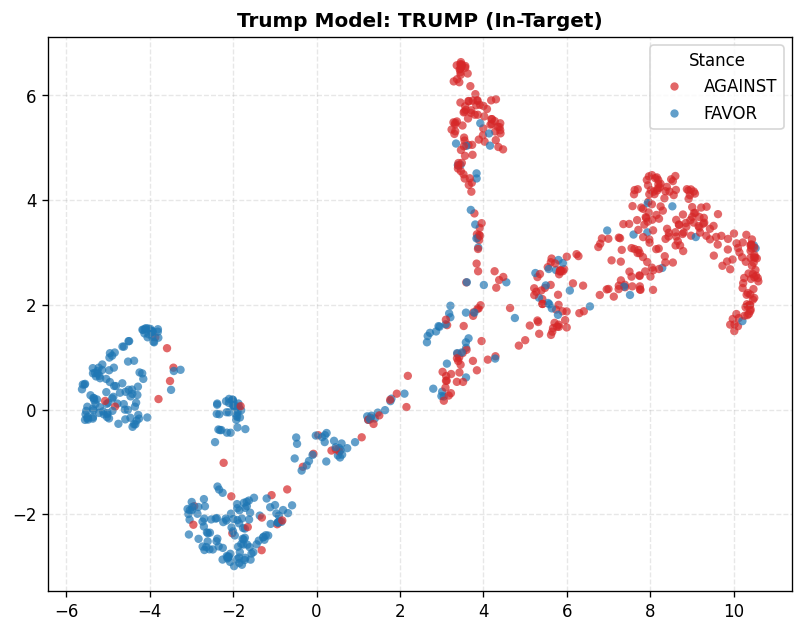

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


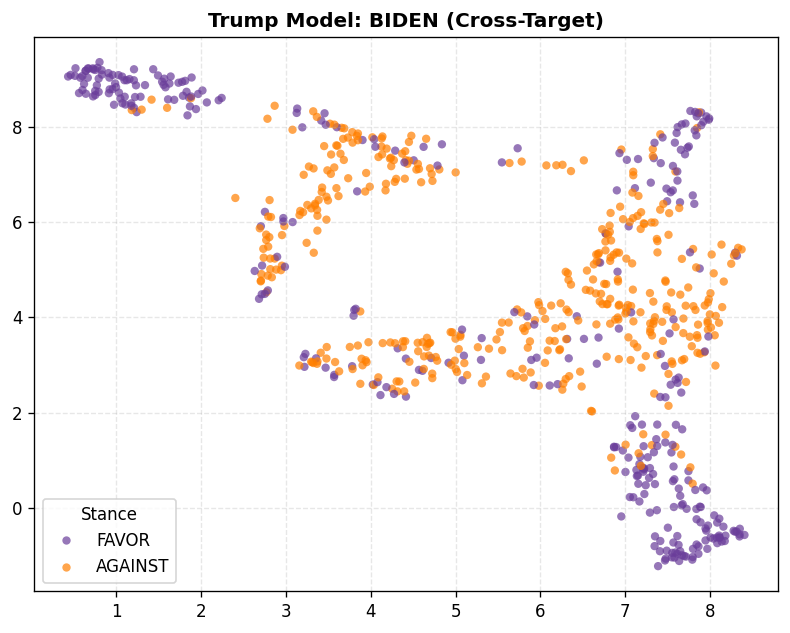

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


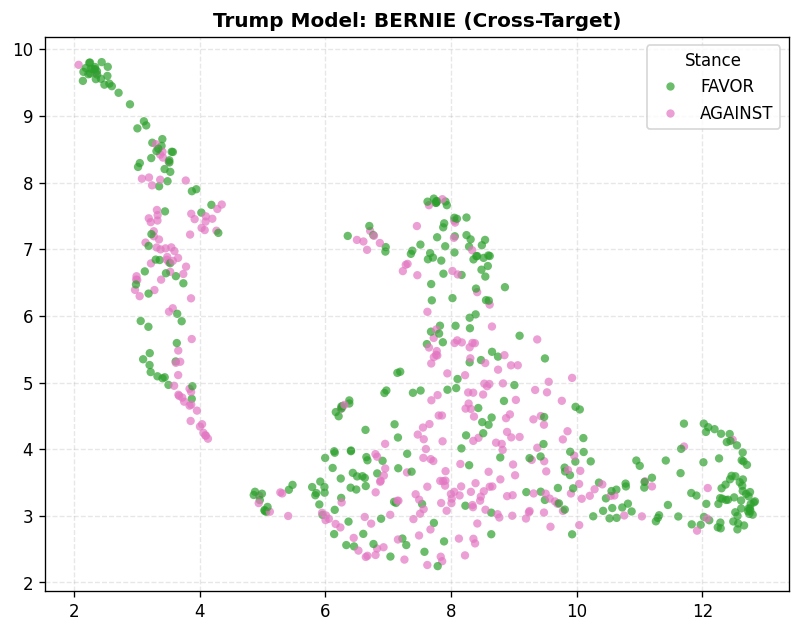

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


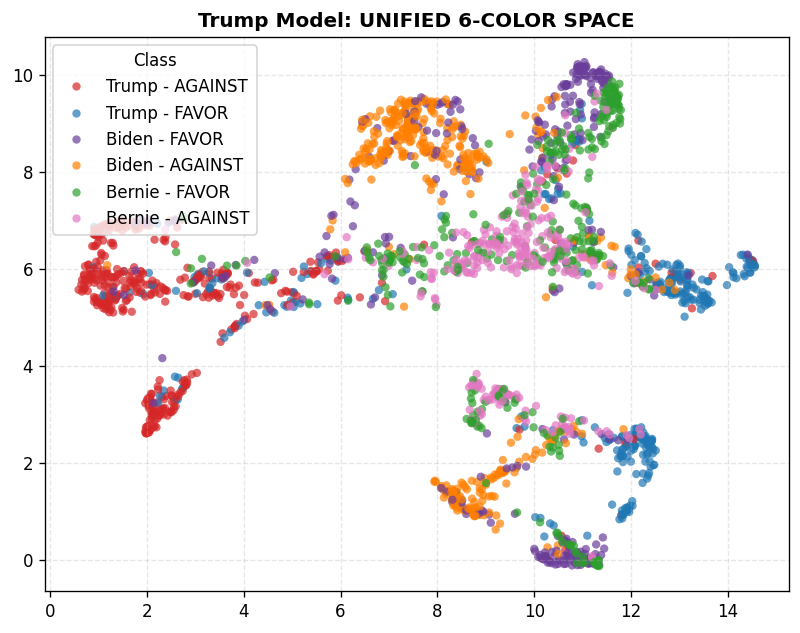

In [ ]:
path = "./roberta-stance-trump"
print(f"Loading Trump Model from {path}...")
model_t = AutoModelForSequenceClassification.from_pretrained(path).to(device)
tok_t = AutoTokenizer.from_pretrained(path)

df_trump_t = testing_trump.copy().assign(Candidate="Trump")
df_biden_t = testing_biden.copy().assign(Candidate="Biden")
df_bernie_t = testing_bernie.copy().assign(Candidate="Bernie")
combined_t = pd.concat([df_trump_t, df_biden_t, df_bernie_t], ignore_index=True)
combined_t["Class"] = combined_t["Candidate"] + " - " + combined_t["Stance"]

# Embeddings
emb_trump = extract_correct_embeddings(model_t, tok_t, df_trump_t, device)
emb_biden = extract_correct_embeddings(model_t, tok_t, df_biden_t, device)
emb_bernie = extract_correct_embeddings(model_t, tok_t, df_bernie_t, device)
emb_all = extract_correct_embeddings(model_t, tok_t, combined_t, device)

def draw_plot(embs, labels, title, palette):
    coords = umap.UMAP(random_state=42).fit_transform(embs)
    plt.figure(figsize=(8, 6), dpi=120)
    sns.scatterplot(x=coords[:,0], y=coords[:,1], hue=labels, palette=palette, alpha=0.7, s=25, edgecolor='none')
    plt.title(title, fontweight='bold')
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.show()

draw_plot(emb_trump, df_trump_t["Stance"], "Trump Model: TRUMP (In-Target)", {"FAVOR": "#1f77b4", "AGAINST": "#d62728"})
draw_plot(emb_biden, df_biden_t["Stance"], "Trump Model: BIDEN (Cross-Target)", {"FAVOR": "#6a3d9a", "AGAINST": "#ff7f00"})
draw_plot(emb_bernie, df_bernie_t["Stance"], "Trump Model: BERNIE (Cross-Target)", {"FAVOR": "#2ca02c", "AGAINST": "#e377c2"})
draw_plot(emb_all, combined_t["Class"], "Trump Model: UNIFIED 6-COLOR SPACE", color_map_6)

# Clear Memory
del model_t, tok_t
if torch.cuda.is_available(): torch.cuda.empty_cache()

# Biden

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import sys
from sklearn.metrics import classification_report
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from torch.utils.data import Dataset as TorchDataset

def load_data(fnames):
    data = []
    for fname in fnames:
        data.append(pd.read_csv(fname, sep=',', encoding='utf-8'))
    data = pd.concat(data)
    return data

label2id = {"FAVOR": 0, "AGAINST": 1}
id2label = {0: "FAVOR", 1: "AGAINST"}

def encode_labels(df):
    df = df.copy()
    df["label"] = df["Stance"].map(label2id)
    return df

class StanceDataset(TorchDataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item
    def __len__(self):
        return len(self.labels)

def tokenize(df, tokenizer):

    return tokenizer(
        df["Tweet"].tolist(),
        df["Target"].tolist(),
        truncation=True,
        padding=True,
        max_length=128
    )

def evaluate_with_trainer(trainer, test_df, tokenizer, target_name):
    print(f"=== Fine-tuned | {target_name} ===")
    test_df = encode_labels(test_df)
    test_encodings = tokenize(test_df, tokenizer)
    test_dataset = StanceDataset(test_encodings, test_df["label"].tolist())

    predictions_output = trainer.predict(test_dataset)
    preds = np.argmax(predictions_output.predictions, axis=-1)

    ground_truth = [id2label[l] for l in test_df["label"].tolist()]
    predictions = [id2label[p] for p in preds]

    print(classification_report(ground_truth, predictions, zero_division=0))

train_file_biden = "/content/drive/MyDrive/PStance/PStance/raw_train_biden.csv"
val_file_biden   = "/content/drive/MyDrive/PStance/PStance/raw_val_biden.csv"

training_biden = encode_labels(load_data([train_file_biden]))
val_biden      = encode_labels(load_data([val_file_biden]))

test_file_trump  = "/content/drive/MyDrive/PStance/PStance/raw_test_trump.csv"
test_file_biden  = "/content/drive/MyDrive/PStance/PStance/raw_test_biden.csv"
test_file_bernie = "/content/drive/MyDrive/PStance/PStance/raw_test_bernie.csv"

testing_trump  = load_data([test_file_trump])
testing_biden  = load_data([test_file_biden])
testing_bernie = load_data([test_file_bernie])

tokenizer = AutoTokenizer.from_pretrained("roberta-large")
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

train_encodings = tokenize(training_biden, tokenizer)
val_encodings   = tokenize(val_biden, tokenizer)

train_dataset = StanceDataset(train_encodings, training_biden["label"].tolist())
val_dataset   = StanceDataset(val_encodings, val_biden["label"].tolist())

model = AutoModelForSequenceClassification.from_pretrained(
    "roberta-large",
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
)

training_args = TrainingArguments(
    output_dir="./roberta-stance-biden-checkpoints",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    fp16=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    save_total_limit=2,
    logging_dir="./logs",
    logging_steps=50,
    report_to="none",
    seed=42,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

print("Starting RoBERTa Fine-Tuning loop on Biden data...")
trainer.train()

trainer.save_model("./roberta-stance-biden")
tokenizer.save_pretrained("./roberta-stance-biden")

evaluate_with_trainer(trainer, testing_biden, tokenizer, "Biden (in-target)")
evaluate_with_trainer(trainer, testing_trump, tokenizer, "Trump (cross-target)")
evaluate_with_trainer(trainer, testing_bernie, tokenizer, "Bernie (cross-target)")

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated

Starting RoBERTa Fine-Tuning loop on Biden data...


Epoch,Training Loss,Validation Loss
1,0.419978,0.399930
2,0.266045,0.373395
3,0.230104,0.548213


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

=== Fine-tuned | Biden (in-target) ===


              precision    recall  f1-score   support

     AGAINST       0.85      0.90      0.88       408
       FAVOR       0.87      0.81      0.84       337

    accuracy                           0.86       745
   macro avg       0.86      0.86      0.86       745
weighted avg       0.86      0.86      0.86       745

=== Fine-tuned | Trump (cross-target) ===


              precision    recall  f1-score   support

     AGAINST       0.69      0.79      0.74       425
       FAVOR       0.69      0.58      0.63       352

    accuracy                           0.69       777
   macro avg       0.69      0.68      0.68       777
weighted avg       0.69      0.69      0.69       777

=== Fine-tuned | Bernie (cross-target) ===


              precision    recall  f1-score   support

     AGAINST       0.68      0.78      0.72       292
       FAVOR       0.78      0.68      0.73       343

    accuracy                           0.73       635
   macro avg       0.73      0.73      0.73       635
weighted avg       0.73      0.73      0.73       635



## Embeddings Visualization (Biden)

Loading Biden Model from ./roberta-stance-biden...


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


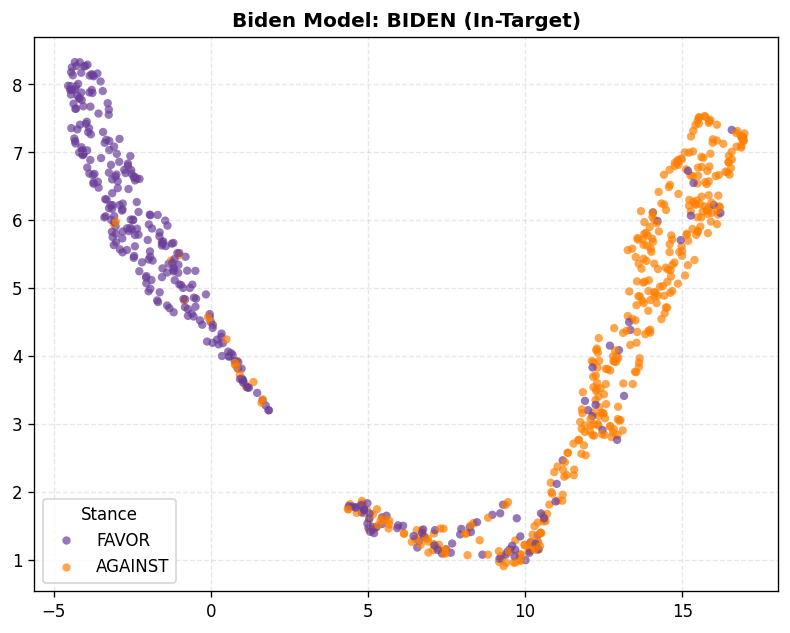

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


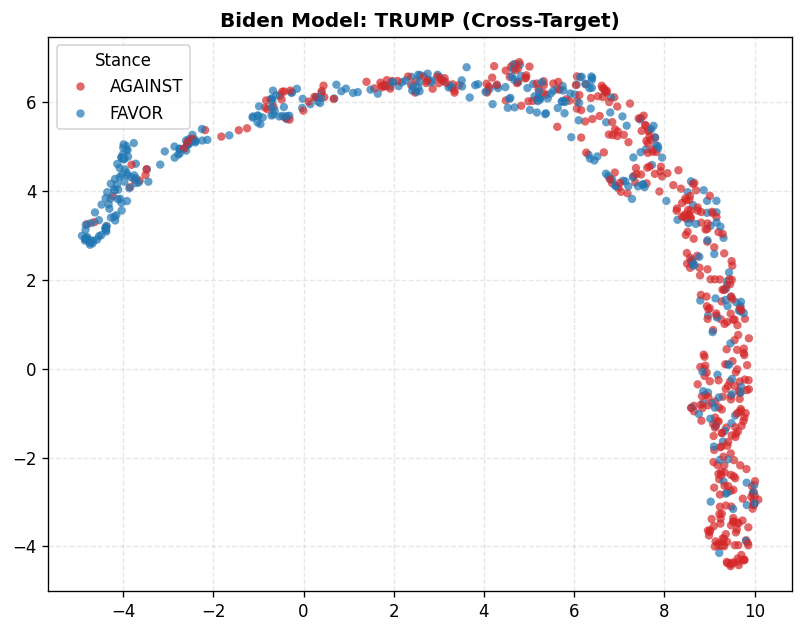

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


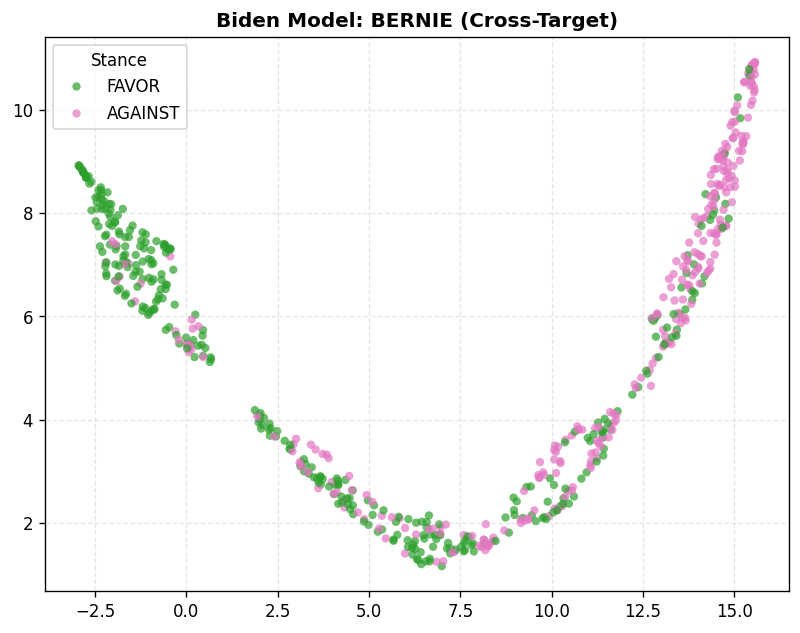

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


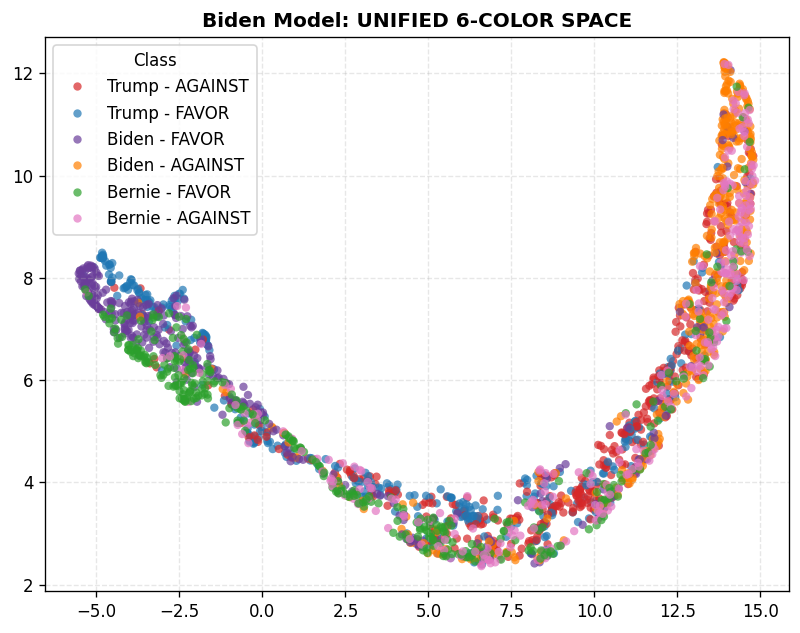

In [ ]:
path = "./roberta-stance-biden"
print(f"Loading Biden Model from {path}...")
model_b = AutoModelForSequenceClassification.from_pretrained(path).to(device)
tok_b = AutoTokenizer.from_pretrained(path)

emb_trump = extract_correct_embeddings(model_b, tok_b, df_trump_t, device)
emb_biden = extract_correct_embeddings(model_b, tok_b, df_biden_t, device)
emb_bernie = extract_correct_embeddings(model_b, tok_b, df_bernie_t, device)
emb_all = extract_correct_embeddings(model_b, tok_b, combined_t, device)

draw_plot(emb_biden, df_biden_t["Stance"], "Biden Model: BIDEN (In-Target)", {"FAVOR": "#6a3d9a", "AGAINST": "#ff7f00"})
draw_plot(emb_trump, df_trump_t["Stance"], "Biden Model: TRUMP (Cross-Target)", {"FAVOR": "#1f77b4", "AGAINST": "#d62728"})
draw_plot(emb_bernie, df_bernie_t["Stance"], "Biden Model: BERNIE (Cross-Target)", {"FAVOR": "#2ca02c", "AGAINST": "#e377c2"})
draw_plot(emb_all, combined_t["Class"], "Biden Model: UNIFIED 6-COLOR SPACE", color_map_6)

# Clear Memory
del model_b, tok_b
if torch.cuda.is_available(): torch.cuda.empty_cache()

# Bernie

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import sys
from sklearn.metrics import classification_report
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from torch.utils.data import Dataset as TorchDataset

def load_data(fnames):
    data = []
    for fname in fnames:
        data.append(pd.read_csv(fname, sep=',', encoding='utf-8'))
    data = pd.concat(data)
    return data

label2id = {"FAVOR": 0, "AGAINST": 1}
id2label = {0: "FAVOR", 1: "AGAINST"}

def encode_labels(df):
    df = df.copy()
    df["label"] = df["Stance"].map(label2id)
    return df

class StanceDataset(TorchDataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item
    def __len__(self):
        return len(self.labels)

def tokenize(df, tokenizer):

    return tokenizer(
        df["Tweet"].tolist(),
        df["Target"].tolist(),
        truncation=True,
        padding=True,
        max_length=128
    )

def evaluate_with_trainer(trainer, test_df, tokenizer, target_name):
    print(f"=== Fine-tuned | {target_name} ===")
    test_df = encode_labels(test_df)
    test_encodings = tokenize(test_df, tokenizer)
    test_dataset = StanceDataset(test_encodings, test_df["label"].tolist())

    predictions_output = trainer.predict(test_dataset)
    preds = np.argmax(predictions_output.predictions, axis=-1)

    ground_truth = [id2label[l] for l in test_df["label"].tolist()]
    predictions = [id2label[p] for p in preds]

    print(classification_report(ground_truth, predictions, zero_division=0))

train_file_bernie = "/content/drive/MyDrive/PStance/PStance/raw_train_bernie.csv"
val_file_bernie   = "/content/drive/MyDrive/PStance/PStance/raw_val_bernie.csv"

training_bernie = encode_labels(load_data([train_file_bernie]))
val_bernie      = encode_labels(load_data([val_file_bernie]))

test_file_trump  = "/content/drive/MyDrive/PStance/PStance/raw_test_trump.csv"
test_file_biden  = "/content/drive/MyDrive/PStance/PStance/raw_test_biden.csv"
test_file_bernie = "/content/drive/MyDrive/PStance/PStance/raw_test_bernie.csv"

testing_trump  = load_data([test_file_trump])
testing_biden  = load_data([test_file_biden])
testing_bernie = load_data([test_file_bernie])

tokenizer = AutoTokenizer.from_pretrained("roberta-large")
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

train_encodings = tokenize(training_bernie, tokenizer)
val_encodings   = tokenize(val_bernie, tokenizer)

train_dataset = StanceDataset(train_encodings, training_bernie["label"].tolist())
val_dataset   = StanceDataset(val_encodings, val_bernie["label"].tolist())

model = AutoModelForSequenceClassification.from_pretrained(
    "roberta-large",
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
)

training_args = TrainingArguments(
    output_dir="./roberta-stance-bernie-checkpoints",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    fp16=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    save_total_limit=2,
    logging_dir="./logs",
    logging_steps=50,
    report_to="none",
    seed=42,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

print("Starting RoBERTa Fine-Tuning loop on Bernie data...")
trainer.train()

trainer.save_model("./roberta-stance-bernie")
tokenizer.save_pretrained("./roberta-stance-bernie")

evaluate_with_trainer(trainer, testing_bernie, tokenizer, "Bernie (in-target)")
evaluate_with_trainer(trainer, testing_trump, tokenizer, "Trump (cross-target)")
evaluate_with_trainer(trainer, testing_biden, tokenizer, "Biden (cross-target)")

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated

Starting RoBERTa Fine-Tuning loop on Bernie data...


Epoch,Training Loss,Validation Loss
1,0.531375,0.456261
2,0.388803,0.484516
3,0.255662,0.542824


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

=== Fine-tuned | Bernie (in-target) ===


              precision    recall  f1-score   support

     AGAINST       0.80      0.72      0.76       292
       FAVOR       0.78      0.84      0.81       343

    accuracy                           0.79       635
   macro avg       0.79      0.78      0.78       635
weighted avg       0.79      0.79      0.79       635

=== Fine-tuned | Trump (cross-target) ===


              precision    recall  f1-score   support

     AGAINST       0.65      0.87      0.74       425
       FAVOR       0.73      0.44      0.55       352

    accuracy                           0.67       777
   macro avg       0.69      0.65      0.65       777
weighted avg       0.69      0.67      0.66       777

=== Fine-tuned | Biden (cross-target) ===


              precision    recall  f1-score   support

     AGAINST       0.77      0.84      0.80       408
       FAVOR       0.78      0.70      0.74       337

    accuracy                           0.77       745
   macro avg       0.78      0.77      0.77       745
weighted avg       0.78      0.77      0.77       745



## Embeddings Visualization (Bernie)

Loading Bernie Model from ./roberta-stance-bernie...


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


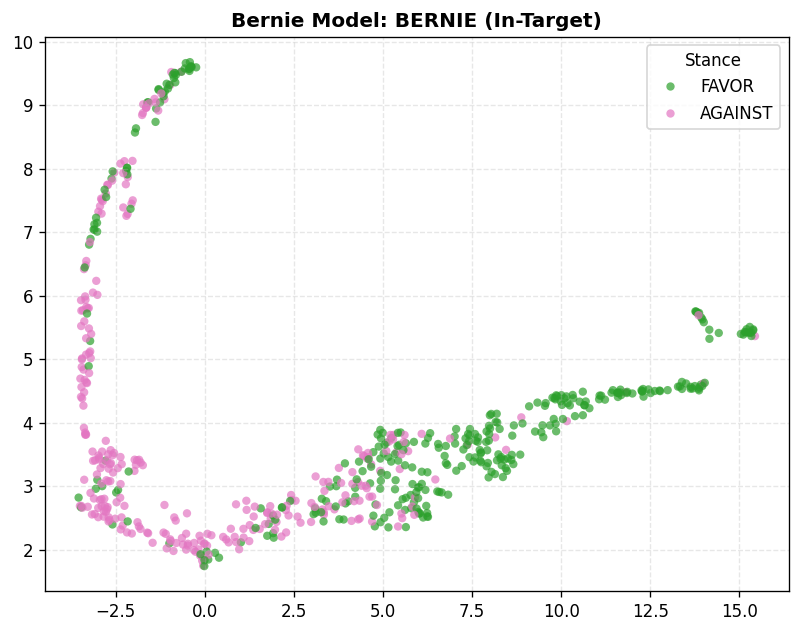

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


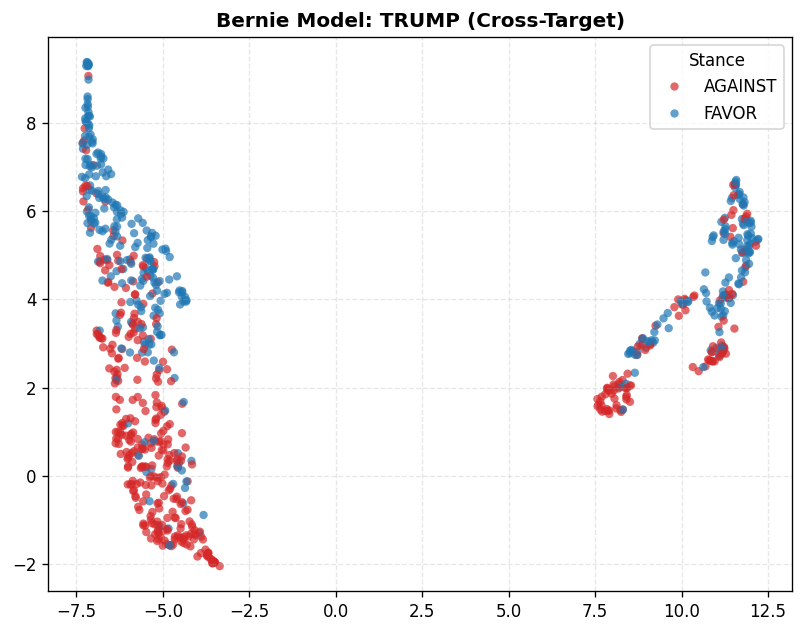

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


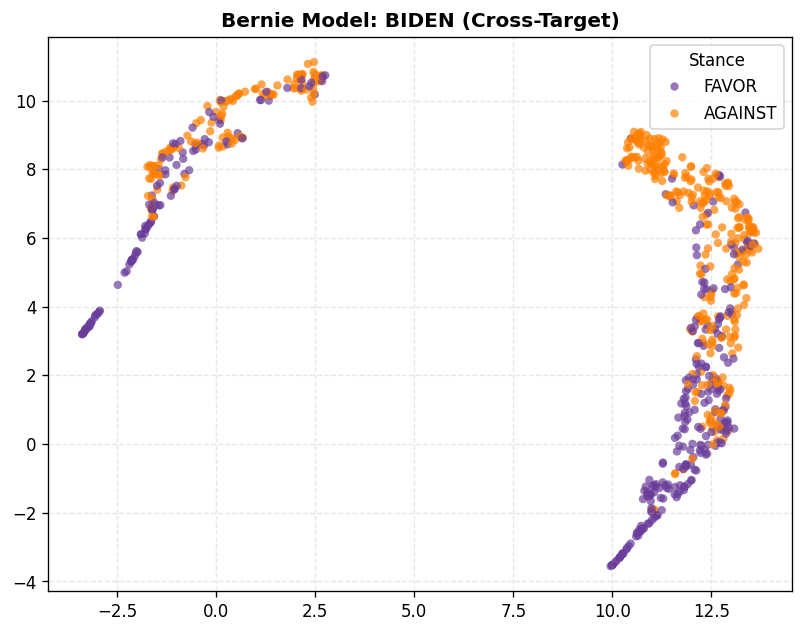

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


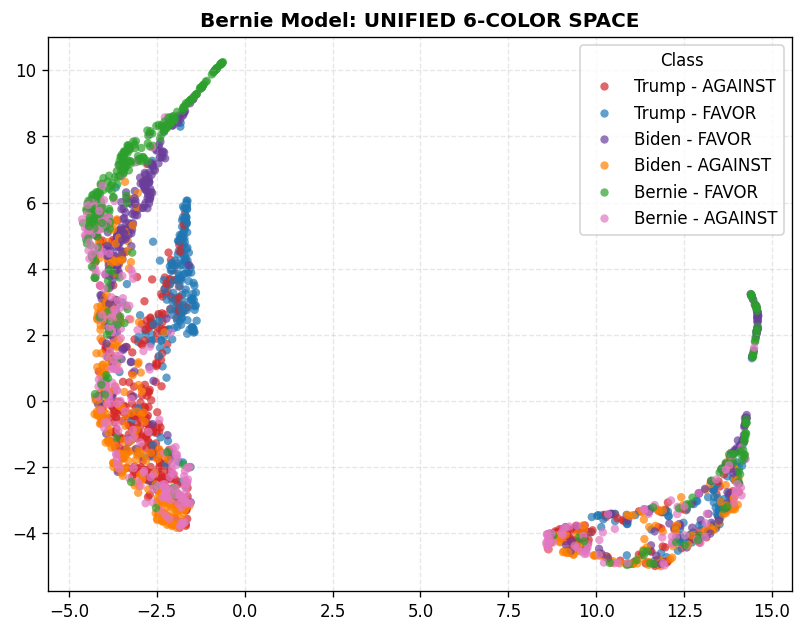

In [ ]:
path = "./roberta-stance-bernie"
print(f"Loading Bernie Model from {path}...")
model_s = AutoModelForSequenceClassification.from_pretrained(path).to(device)
tok_s = AutoTokenizer.from_pretrained(path)

emb_trump = extract_correct_embeddings(model_s, tok_s, df_trump_t, device)
emb_biden = extract_correct_embeddings(model_s, tok_s, df_biden_t, device)
emb_bernie = extract_correct_embeddings(model_s, tok_s, df_bernie_t, device)
emb_all = extract_correct_embeddings(model_s, tok_s, combined_t, device)

draw_plot(emb_bernie, df_bernie_t["Stance"], "Bernie Model: BERNIE (In-Target)", {"FAVOR": "#2ca02c", "AGAINST": "#e377c2"})
draw_plot(emb_trump, df_trump_t["Stance"], "Bernie Model: TRUMP (Cross-Target)", {"FAVOR": "#1f77b4", "AGAINST": "#d62728"})
draw_plot(emb_biden, df_biden_t["Stance"], "Bernie Model: BIDEN (Cross-Target)", {"FAVOR": "#6a3d9a", "AGAINST": "#ff7f00"})
draw_plot(emb_all, combined_t["Class"], "Bernie Model: UNIFIED 6-COLOR SPACE", color_map_6)

del model_s, tok_s
if torch.cuda.is_available(): torch.cuda.empty_cache()

# Visualizing All Embeddings

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


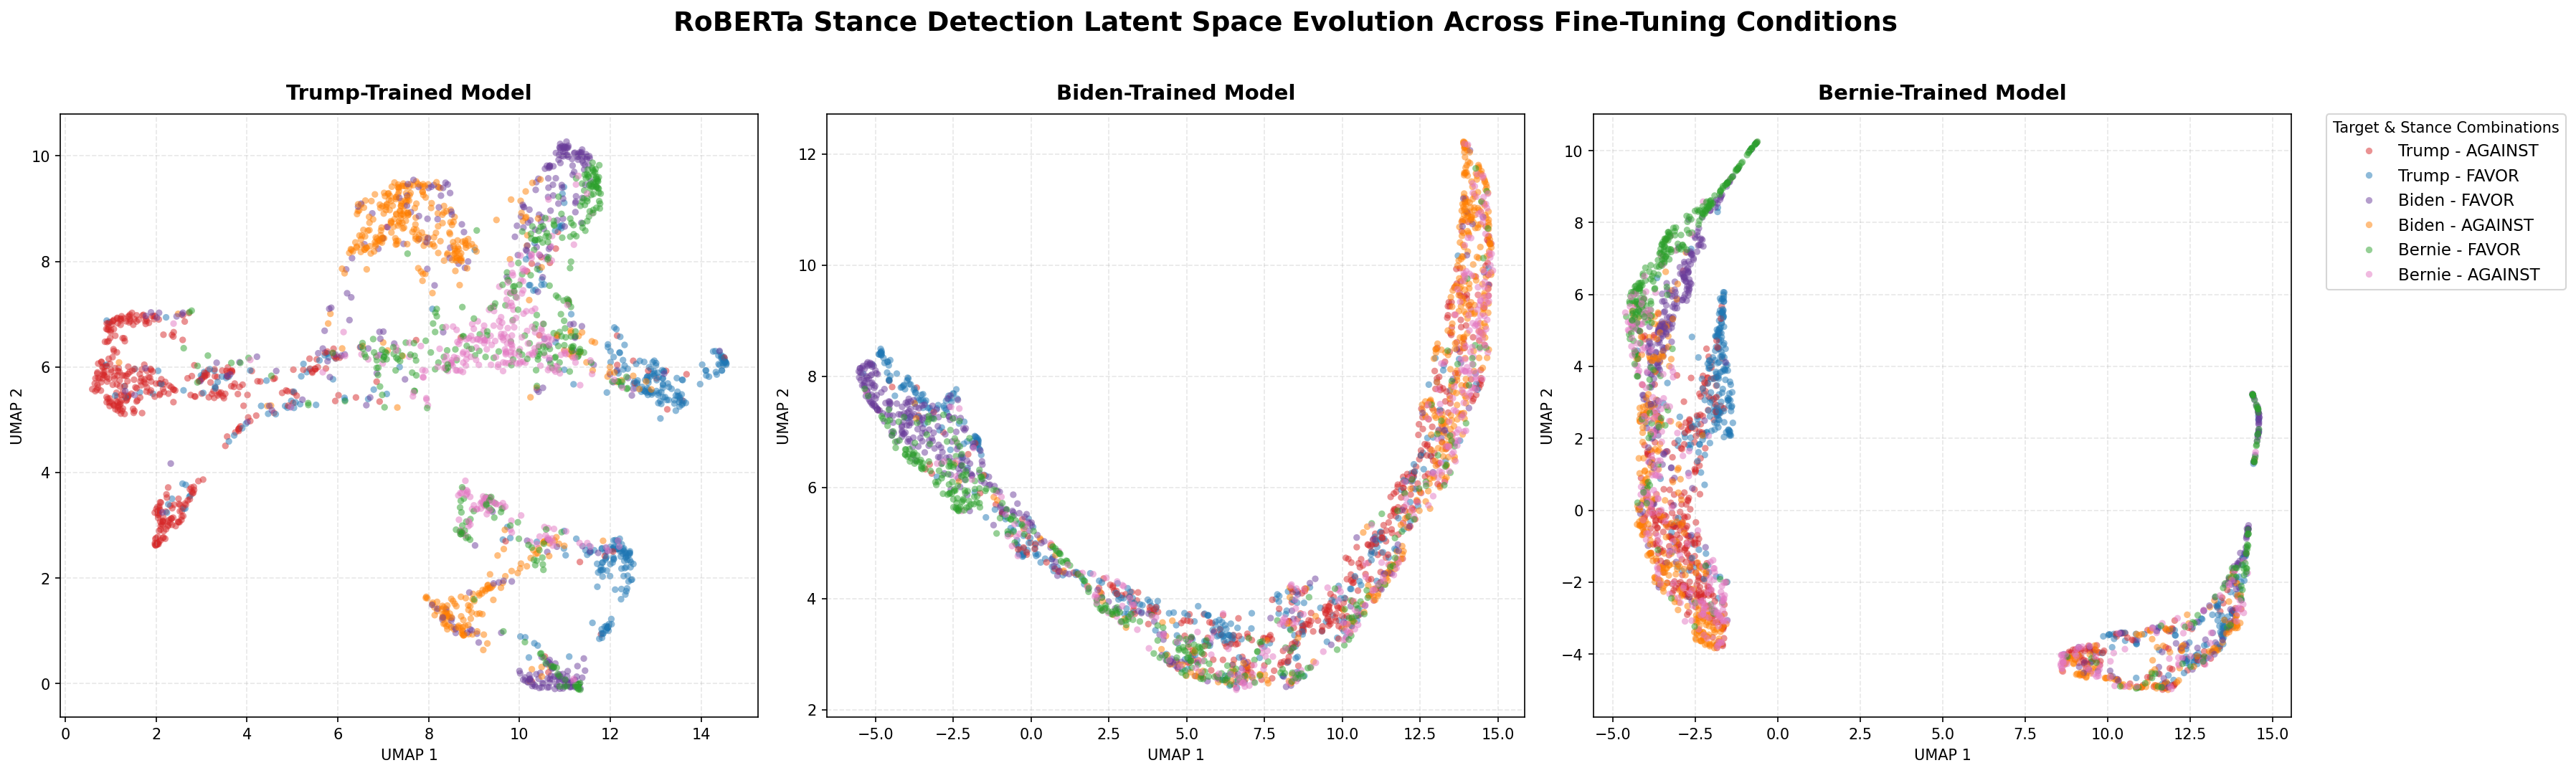

In [ ]:
model_paths = {
    "Trump-Trained Model": "./roberta-stance-trump",
    "Biden-Trained Model": "./roberta-stance-biden",
    "Bernie-Trained Model": "./roberta-stance-bernie"
}

fig, axes = plt.subplots(1, 3, figsize=(24, 7), dpi=150)

for idx, (title, path) in enumerate(model_paths.items()):
    if not os.path.exists(path): continue

    local_tokenizer = AutoTokenizer.from_pretrained(path)
    local_model = AutoModelForSequenceClassification.from_pretrained(path).to(device)

    embeddings = extract_correct_embeddings(local_model, local_tokenizer, combined_t, device=device)
    umap_coords = umap.UMAP(random_state=42).fit_transform(embeddings)

    plot_df = pd.DataFrame({
        "UMAP 1": umap_coords[:, 0], "UMAP 2": umap_coords[:, 1], "Class": combined_t["Class"].tolist()
    })

    sns.scatterplot(
        data=plot_df, x="UMAP 1", y="UMAP 2", hue="Class",
        palette=color_map_6, alpha=0.5, s=20, edgecolor='none',
        ax=axes[idx], legend=(idx == 2)
    )

    axes[idx].set_title(title, fontsize=14, fontweight='bold', pad=10)
    axes[idx].grid(True, linestyle="--", alpha=0.3)

    del local_model, local_tokenizer
    if torch.cuda.is_available(): torch.cuda.empty_cache()

if axes[2].get_legend() is not None:
    axes[2].legend(title="Target & Stance Combinations", bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=11)

plt.suptitle("RoBERTa Stance Detection Latent Space Evolution Across Fine-Tuning Conditions", fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

The Trump trained model breaks the data into a complex and multi-classes web because Trump's political vocabulary is highly unique and polarized and the model creates highly localized semantic boundaries. So it maps specific vocabulary clusters into tight, separate neighborhood zones. On the other hand, Biden trained model warps the space into a smooth and continuous U shape. Biden's rhetorical style and the tweets surrounding him represent institutional political discourse and the model doesn't see fragmented classes, but it aligns political language along a continuous spectrum—stretching from opposition to support. As opposed to Biden, Bernie trained model structures the data in two large vertical structures on opposite sides. Bernie represents a sharp ideological dividing line, left vs. right. The model reflects this by polarizing the language, pulling tweets into two distinct ideological fields with an empty space in between.

# In-target & Cross-Target Evaluation (Macro F1 Scores)



In [ ]:
test_dataframes = {
    "Trump": testing_trump,
    "Biden": testing_biden,
    "Bernie": testing_bernie
}

all_f1_results = []

for model_name, model_path in model_paths.items():
    if not os.path.exists(model_path):
        print(f"Model {model_name} not found at {model_path}. Skipping evaluation.")
        continue

    for test_target_name, test_df in test_dataframes.items():
        f1_score = get_macro_f1(
            model_path,
            test_df,
            f"{model_name} model on {test_target_name} data"
        )
        if f1_score is not None:
            all_f1_results.append({
                'Trained Model': model_name,
                'Tested On': test_target_name,
                'Macro F1 Score': f1_score
            })

f1_comparison_df = pd.DataFrame(all_f1_results)

print("\n--- Macro F1 Scores Comparison ---")
display(f1_comparison_df.pivot(index='Trained Model', columns='Tested On', values='Macro F1 Score').fillna(0).round(4))

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Evaluated Trump model on Trump data (model from ./roberta-stance-trump): Macro F1 = 0.8669


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Evaluated Trump model on Biden data (model from ./roberta-stance-trump): Macro F1 = 0.4792


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Evaluated Bernie model on Biden data (model from ./roberta-stance-bernie): Macro F1 = 0.7697


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Evaluated Bernie model on Bernie data (model from ./roberta-stance-bernie): Macro F1 = 0.7841

--- Macro F1 Scores Comparison ---


Tested On,Bernie,Biden,Trump
Trained Model,,,
Bernie,0.7841,0.7697,0.6465
Biden,0.7260,0.8581,0.6847
Trump,0.4129,0.4792,0.8669


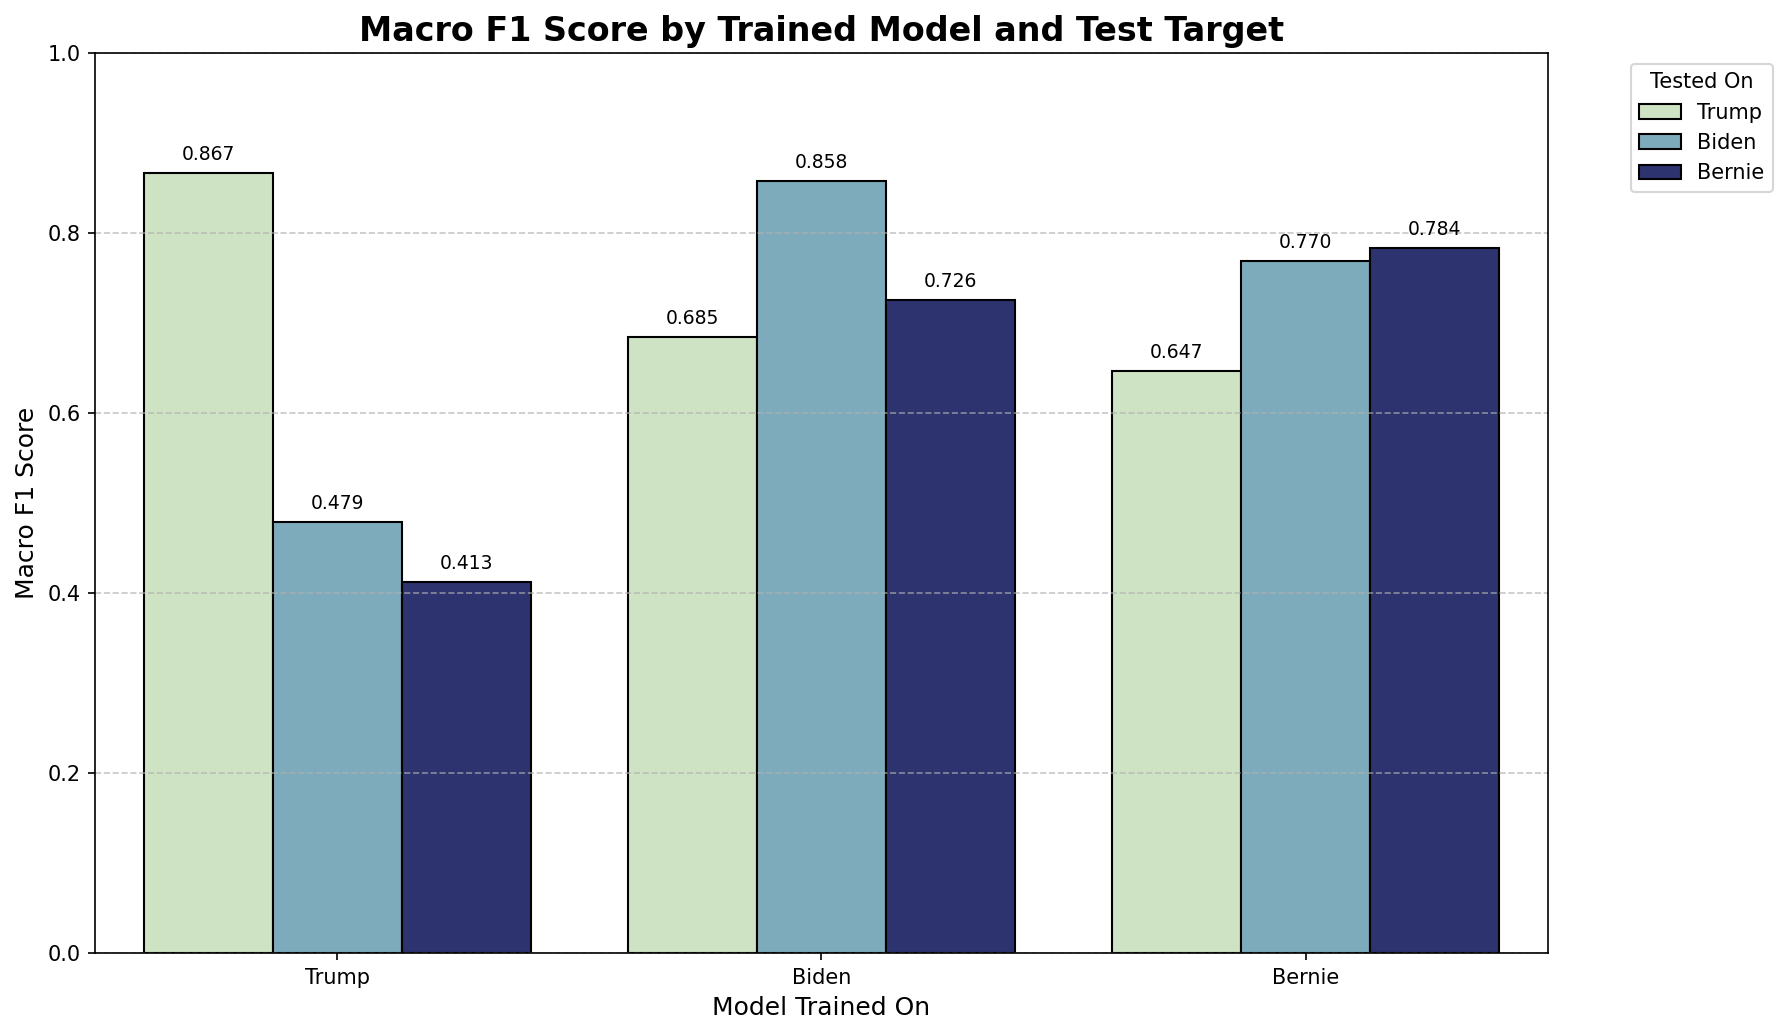

In [ ]:
plt.figure(figsize=(12, 7), dpi=150)
sns.barplot(
    x='Trained Model',
    y='Macro F1 Score',
    hue='Tested On',
    data=f1_comparison_df,
    palette=colors,
    edgecolor='black'
)

plt.title('Macro F1 Score by Trained Model and Test Target', fontsize=16, fontweight='bold')
plt.xlabel('Model Trained On', fontsize=12)
plt.ylabel('Macro F1 Score', fontsize=12)
plt.ylim(0, 1) # F1 score is between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Tested On', bbox_to_anchor=(1.05, 1), loc='upper left')

for container in plt.gca().containers:
    for patch in container.patches:
        height = patch.get_height()
        if height > 0: # Only add text for non-zero scores
            plt.text(patch.get_x() + patch.get_width() / 2.,
                     height + 0.01,
                     f'{height:.3f}',
                     ha='center', va='bottom', color='black', fontsize=9)

plt.tight_layout()
plt.show()